In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FixedLocator
import pandas as pd

files = {
    'Native': '/home/mengelsl/MA-bench-framework/outputs/krylov/native3/summary_krylov.csv',
    'SME': '/home/mengelsl/MA-bench-framework/outputs/krylov/20260215_150353/summary_krylov.csv', 
    'SEV': '/home/mengelsl/MA-bench-framework/outputs/krylov/sev2/summary_krylov.csv'
}

dfs = []

for mode, path in files.items():
    temp_df = pd.read_csv(path)
    temp_df.insert(0, 'Mode', mode)
    dfs.append(temp_df)

df_raw = pd.concat(dfs, ignore_index=True)
df_raw['total_time'] = df_raw['SpMVTime'] + df_raw['MgmtTime']

def get_median_time_run(group):
    return group.loc[(group['total_time']- group['total_time'].median()).abs().idxmin()]

group_cols = ['Mode', 'Algo', 'Matrix', 'Cores', 'NUMA', 'Arg1', 'Arg2', 'Arg3']
df_med = df_raw.groupby(group_cols, group_keys=False).apply(get_median_time_run, include_groups=False).reset_index()

df_med['ns_per_op'] = ((df_med['total_time']) * 1e9) / df_med['N_Ops']
df_med.drop(columns=['Run'], inplace=True)
df = df_med.copy()

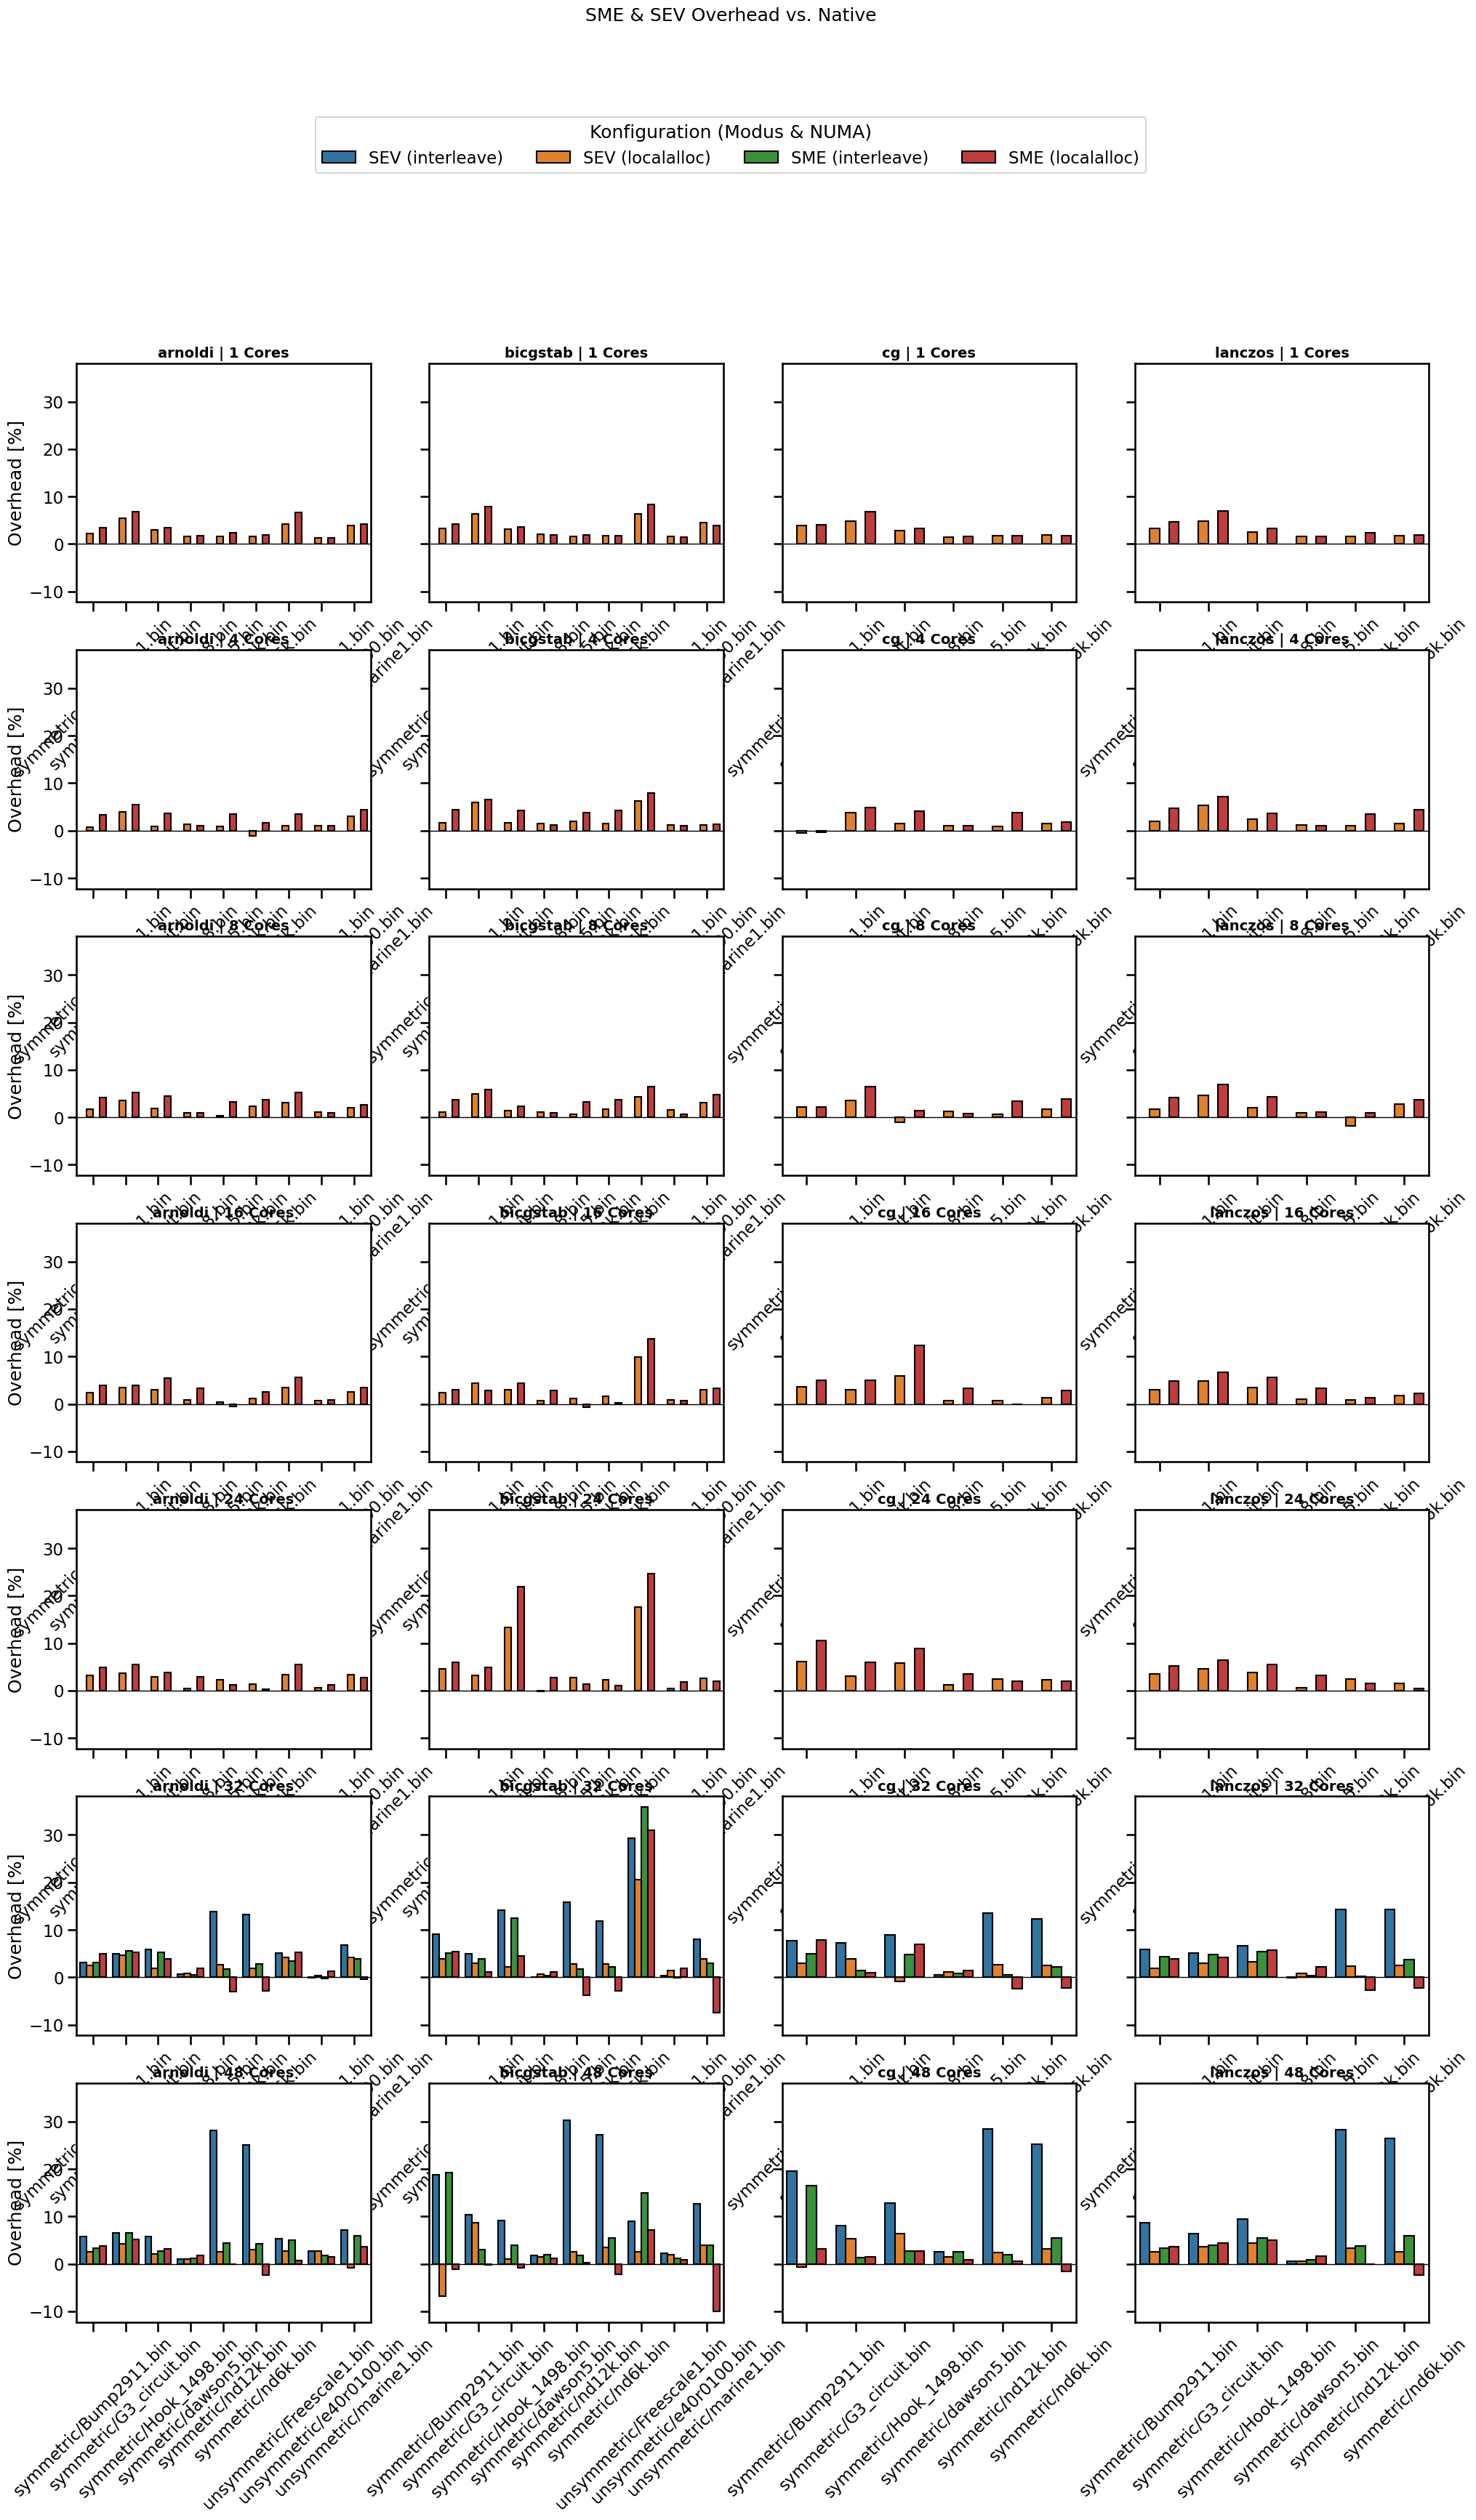

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Spalten für den Join
match_cols = ['Algo', 'Matrix', 'Cores', 'NUMA', 'Arg1', 'Arg2', 'Arg3']

# 2. Native Referenz isolieren
native_ref = df[df['Mode'] == 'Native'][match_cols + ['ns_per_op']].rename(
    columns={'ns_per_op': 'native_ns_per_op'}
)

# 3. SME und SEV Daten isolieren und Mergen
encrypted_df = df[df['Mode'].isin(['SME', 'SEV'])].copy()
df_ov = encrypted_df.merge(native_ref, on=match_cols, how='inner')

# 4. Overhead berechnen und Config-String erstellen
df_ov['overhead_pct'] = (df_ov['ns_per_op'] / df_ov['native_ns_per_op'] - 1) * 100
df_ov['Config'] = df_ov['Mode'] + " (" + df_ov['NUMA'] + ")"

# WICHTIG: Festlegen der Reihenfolge, damit die Farben konsistent bleiben
config_order = sorted(df_ov['Config'].unique())
df_ov['Config'] = pd.Categorical(df_ov['Config'], categories=config_order, ordered=True)

# 5. Plot-Vorbereitung
df_plot = df_ov.sort_values(['Algo', 'Cores', 'Matrix', 'Config'])
cores = sorted(df_ov['Cores'].unique())
algos = sorted(df_ov['Algo'].unique())

fig, axes = plt.subplots(len(cores), len(algos), 
                         figsize=(8 * len(algos), 6 * len(cores)), 
                         sharey=False)

if len(cores) == 1: axes = [axes]
if len(algos) == 1: axes = [[ax] for ax in axes]

for i, c in enumerate(cores):
    for j, a in enumerate(algos):
        ax = axes[i][j]
        d = df_plot[(df_plot['Cores'] == c) & (df_plot['Algo'] == a)]
        
        if d.empty:
            ax.set_visible(False)
            continue
            
        # Wir nutzen die automatische Palette, erzwingen aber die hue_order
        sns.barplot(data=d, x='Matrix', y='overhead_pct', hue='Config', 
                    hue_order=config_order, edgecolor='black', ax=ax)
        
        ax.axhline(0, color='black', linewidth=1)
        ax.set_title(f'{a} | {c} Cores', fontsize=14, fontweight='bold')
        ax.set_xlabel('')
        ax.set_ylabel('Overhead [%]' if j == 0 else '')
        ax.tick_params(axis='x', rotation=45)
        
        # Legende im Subplot entfernen
        if ax.get_legend():
            ax.get_legend().remove()

# 6. Die zentrale Legende oben
# Wir holen uns die Handles vom allerersten Subplot
handles, labels = axes[0][0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=len(config_order), 
           bbox_to_anchor=(0.5, 0.98), title='Konfiguration (Modus & NUMA)')

fig.suptitle('SME & SEV Overhead vs. Native', fontsize=18, y=1.02)

plt.tight_layout(rect=[0, 0, 1, 0.96], pad=2.0, h_pad=3.0, w_pad=3.0)
plt.show()

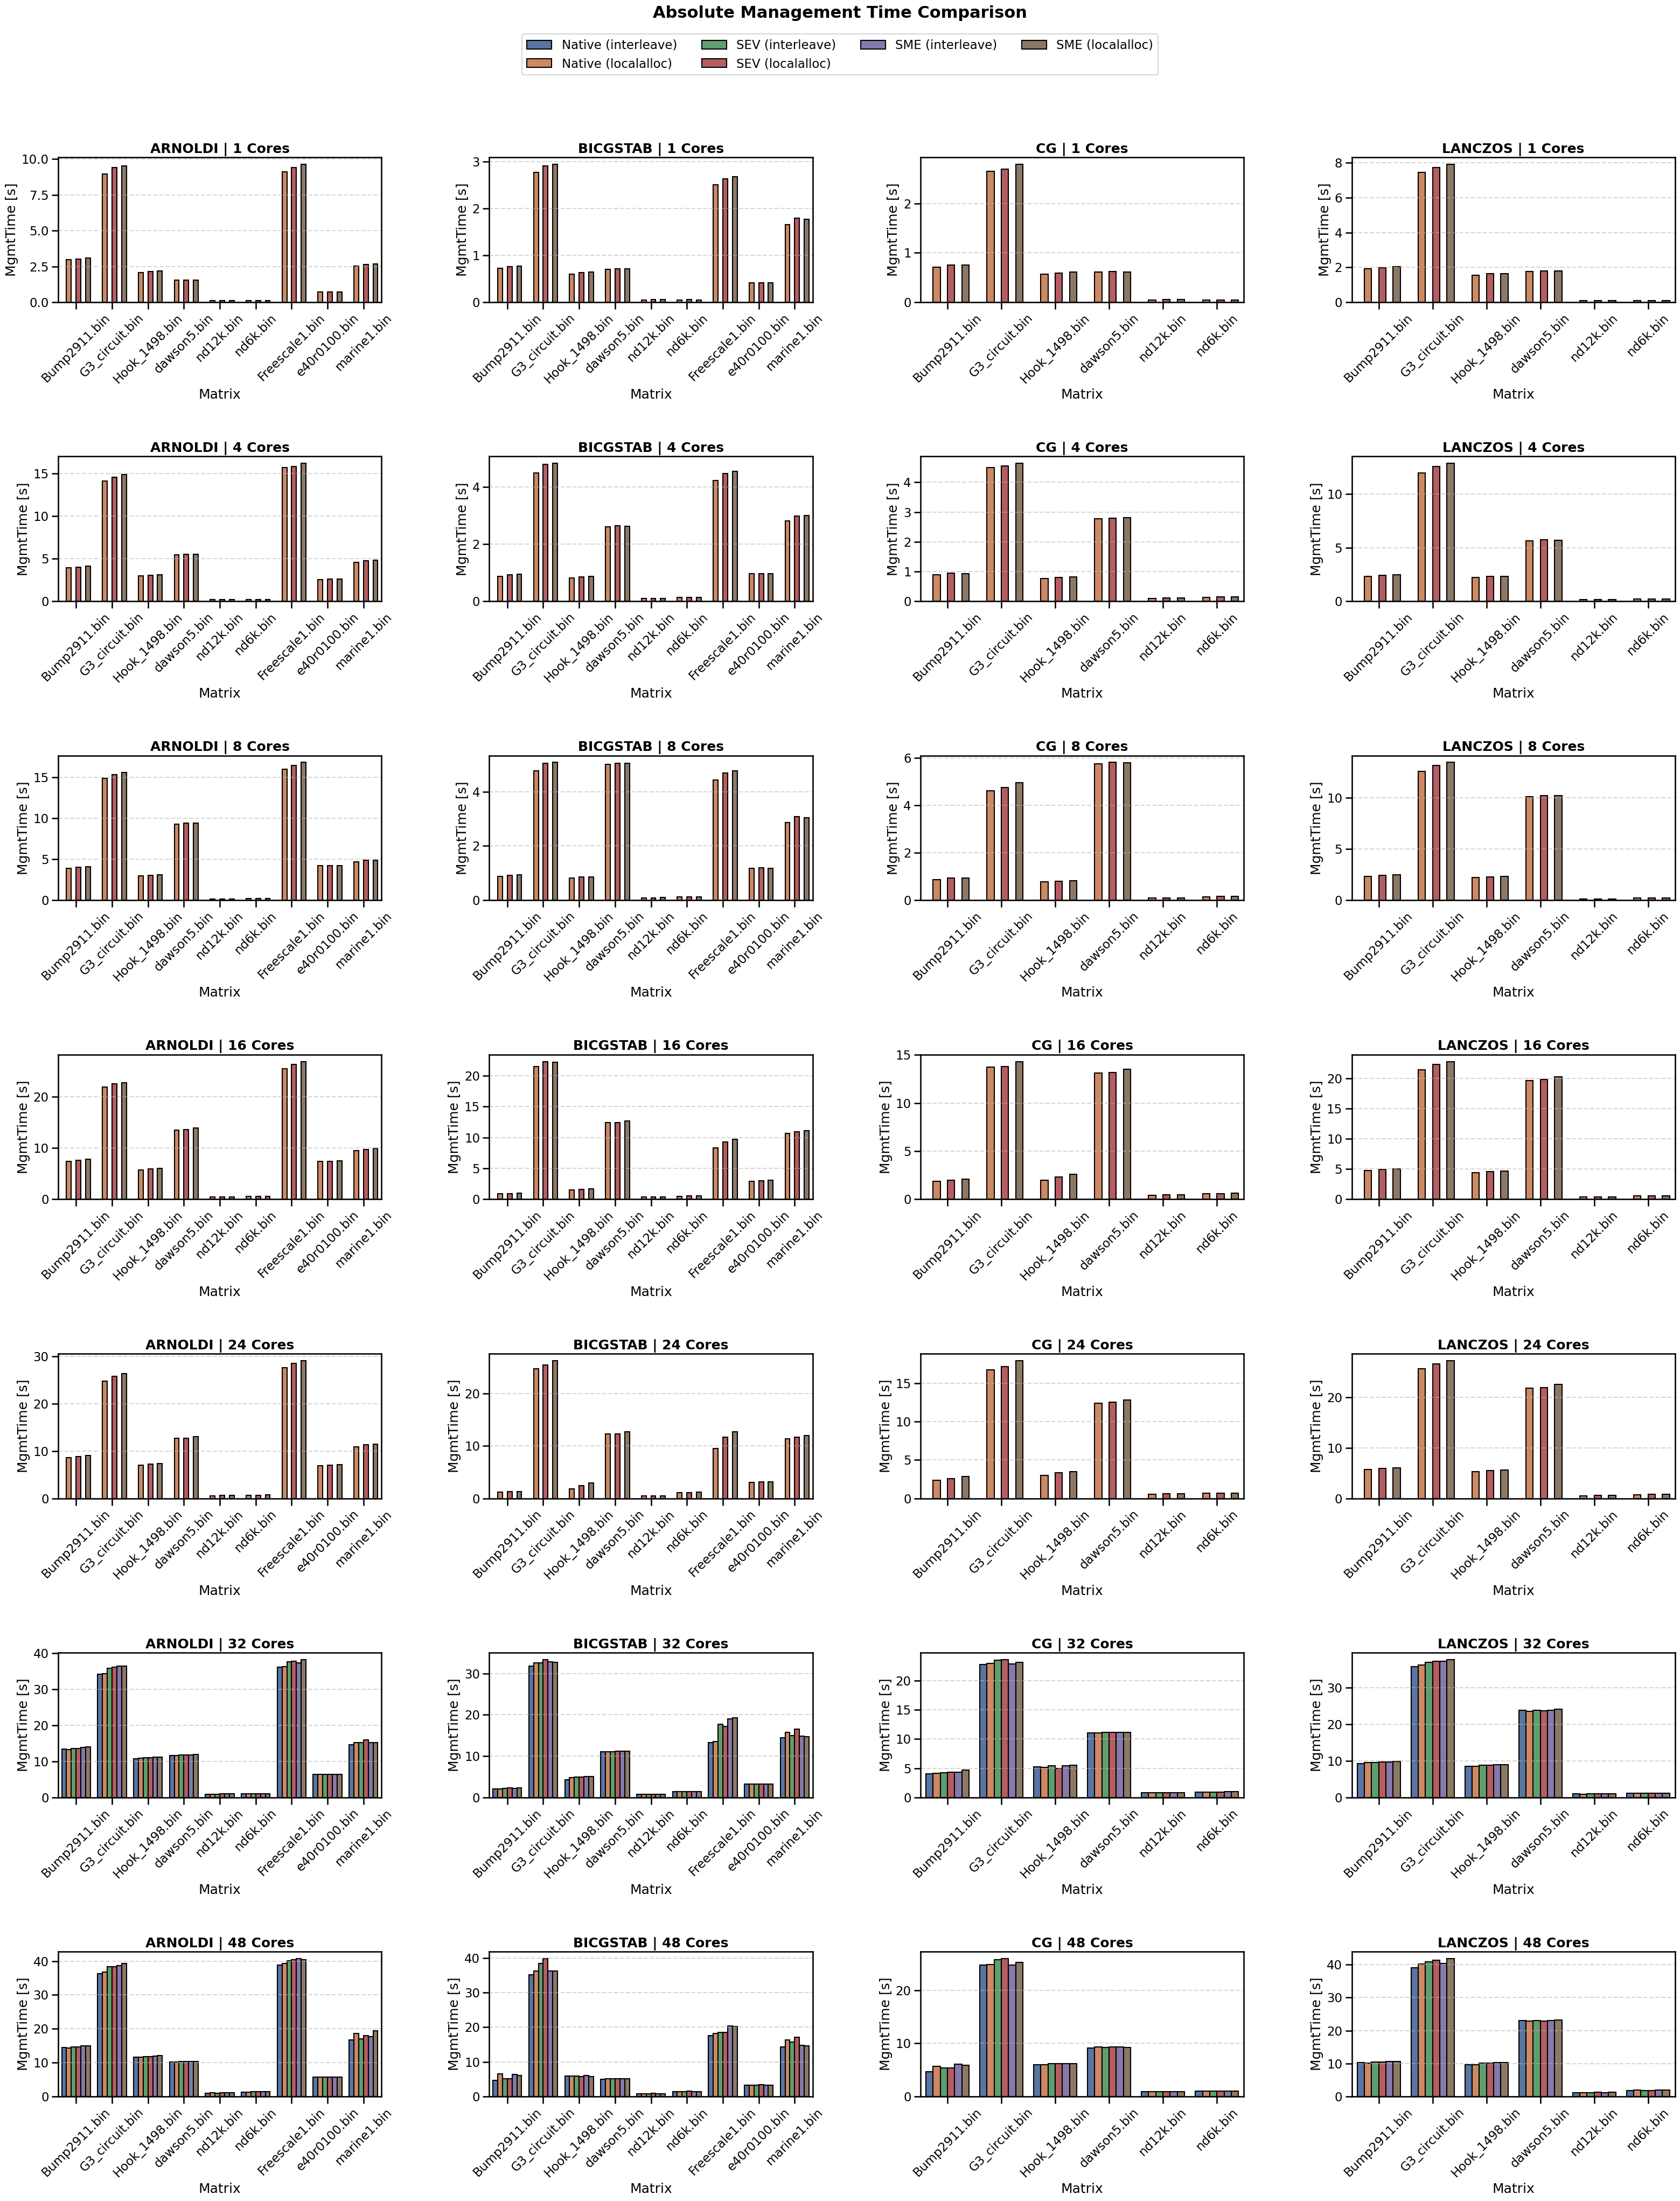

In [70]:
# ========= PREP =========
plot_df = df.copy()

# Labels
plot_df['Matrix_Label'] = plot_df['Matrix'].str.split('/').str[-1]
plot_df['Algo'] = plot_df['Algo'].str.upper()
plot_df['Legend_Label'] = plot_df['Mode'] + " (" + plot_df['NUMA'] + ")"

# globale Hue-Reihenfolge für konsistente Farben
hue_order = sorted(plot_df['Legend_Label'].unique())

# ========= GRID =========
unique_cores = sorted(plot_df['Cores'].unique())
unique_algos = sorted(plot_df['Algo'].unique())

n_rows = len(unique_cores)
n_cols = len(unique_algos)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(8 * n_cols, 6 * n_rows),
    sharey=False
)

axes = np.atleast_2d(axes)

# ========= PLOT =========
for i, core in enumerate(unique_cores):
    for j, algo in enumerate(unique_algos):

        ax = axes[i, j]

        data = plot_df[
            (plot_df['Cores'] == core) &
            (plot_df['Algo'] == algo)
        ]

        if data.empty:
            ax.set_visible(False)
            continue

        sns.barplot(
            data=data,
            x='Matrix_Label',
            y='MgmtTime',  # 🔥 hier geändert
            hue='Legend_Label',
            hue_order=hue_order,
            palette='deep',
            edgecolor='black',
            ax=ax
        )

        # optional: log scale falls große Unterschiede
        # ax.set_yscale("log")

        # grid
        ax.grid(axis='y', linestyle='--', alpha=0.5, which="both")

        # styling
        ax.set_title(f"{algo} | {core} Cores", fontweight='bold')
        ax.set_xlabel("Matrix")
        ax.set_ylabel("MgmtTime [s]")
        ax.tick_params(axis='x', rotation=45)

        # lokale Legende entfernen
        if ax.get_legend():
            ax.get_legend().remove()

# ========= GLOBAL LEGEND =========
handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc='upper center',
    ncol=4,
    bbox_to_anchor=(0.5, 0.97),
    frameon=True
)

fig.suptitle(
    "Absolute Management Time Comparison",
    fontsize=22,
    fontweight='bold'
)

plt.tight_layout(rect=[0, 0, 1, 0.95], pad=2.0, h_pad=3.0, w_pad=3.0)
plt.show()

In [5]:
# ns/op berechnen
df_raw['ns_per_op'] = (df_raw['total_time'] * 1e9) / df_raw['N_Ops']

# ========= STATS =========
stats_df = df_raw.groupby(
    ['Mode', 'Algo', 'Matrix', 'Cores', 'NUMA']
).agg(
    ns_med=('ns_per_op', 'median')
).reset_index()

# ========= PIVOT =========
ns_pivot = stats_df.pivot_table(
    index=['Algo', 'Matrix', 'Cores', 'NUMA'],
    columns='Mode',
    values='ns_med'
).reset_index()

final_df = ns_pivot.copy()

# ========= OVERHEADS =========
final_df['SME_vs_Native_%'] = (final_df['SME'] / final_df['Native'] - 1) * 100
final_df['SEV_vs_Native_%'] = (final_df['SEV'] / final_df['Native'] - 1) * 100
final_df['SEV_vs_SME_%'] = (final_df['SEV'] / final_df['SME'] - 1) * 100

# ========= COLOR FUNCTION =========
def apply_distinct_colors(val):
    if pd.isna(val):
        return ''
    if val >= 0.5:   # langsamer → rot
        return 'background-color: #ffcccc; color: #cc0000; font-weight: bold'
    elif val <= -0.5:  # schneller → grün
        return 'background-color: #ccffcc; color: #006600; font-weight: bold'
    return 'background-color: #f2f2f2; color: #666666'

# ========= DISPLAY =========
diff_cols = ['SME_vs_Native_%', 'SEV_vs_Native_%', 'SEV_vs_SME_%']

display_cols = [
    'Algo', 'Matrix', 'Cores', 'NUMA',
    'Native', 'SME', 'SEV'
] + diff_cols

styled_final = final_df[display_cols].sort_values(
    ['NUMA', 'Cores', 'Algo']
).style\
    .format({
        'Native': '{:.2f}',
        'SME': '{:.2f}',
        'SEV': '{:.2f}',
        'SME_vs_Native_%': '{:+.2f}%',
        'SEV_vs_Native_%': '{:+.2f}%',
        'SEV_vs_SME_%': '{:+.2f}%'
    })\
    .map(apply_distinct_colors, subset=diff_cols)\
    .set_caption("ns/op Median & Overheads")

display(styled_final)


Mode,Algo,Matrix,Cores,NUMA,Native,SME,SEV,SME_vs_Native_%,SEV_vs_Native_%,SEV_vs_SME_%
5,arnoldi,symmetric/Bump2911.bin,32,interleave,50193025.94,52123659.94,52157881.84,+3.85%,+3.91%,+0.07%
14,arnoldi,symmetric/G3_circuit.bin,32,interleave,15146076.10,15974546.18,15900810.54,+5.47%,+4.98%,-0.46%
23,arnoldi,symmetric/Hook_1498.bin,32,interleave,21700696.30,22846874.07,22972903.70,+5.28%,+5.86%,+0.55%
32,arnoldi,symmetric/dawson5.bin,32,interleave,455718.82,458106.31,458432.02,+0.52%,+0.60%,+0.07%
41,arnoldi,symmetric/nd12k.bin,32,interleave,1237033.36,1257700.29,1412054.84,+1.67%,+14.15%,+12.27%
50,arnoldi,symmetric/nd6k.bin,32,interleave,516095.27,530269.46,584069.04,+2.75%,+13.17%,+10.15%
59,arnoldi,unsymmetric/Freescale1.bin,32,interleave,40970882.35,42546328.60,42797748.48,+3.85%,+4.46%,+0.59%
68,arnoldi,unsymmetric/e40r0100.bin,32,interleave,160199.53,159820.96,159926.33,-0.24%,-0.17%,+0.07%
77,arnoldi,unsymmetric/marine1.bin,32,interleave,2921159.53,3035761.49,3118440.84,+3.92%,+6.75%,+2.72%
86,bicgstab,symmetric/Bump2911.bin,32,interleave,37456083.92,39350139.86,40863846.15,+5.06%,+9.10%,+3.85%


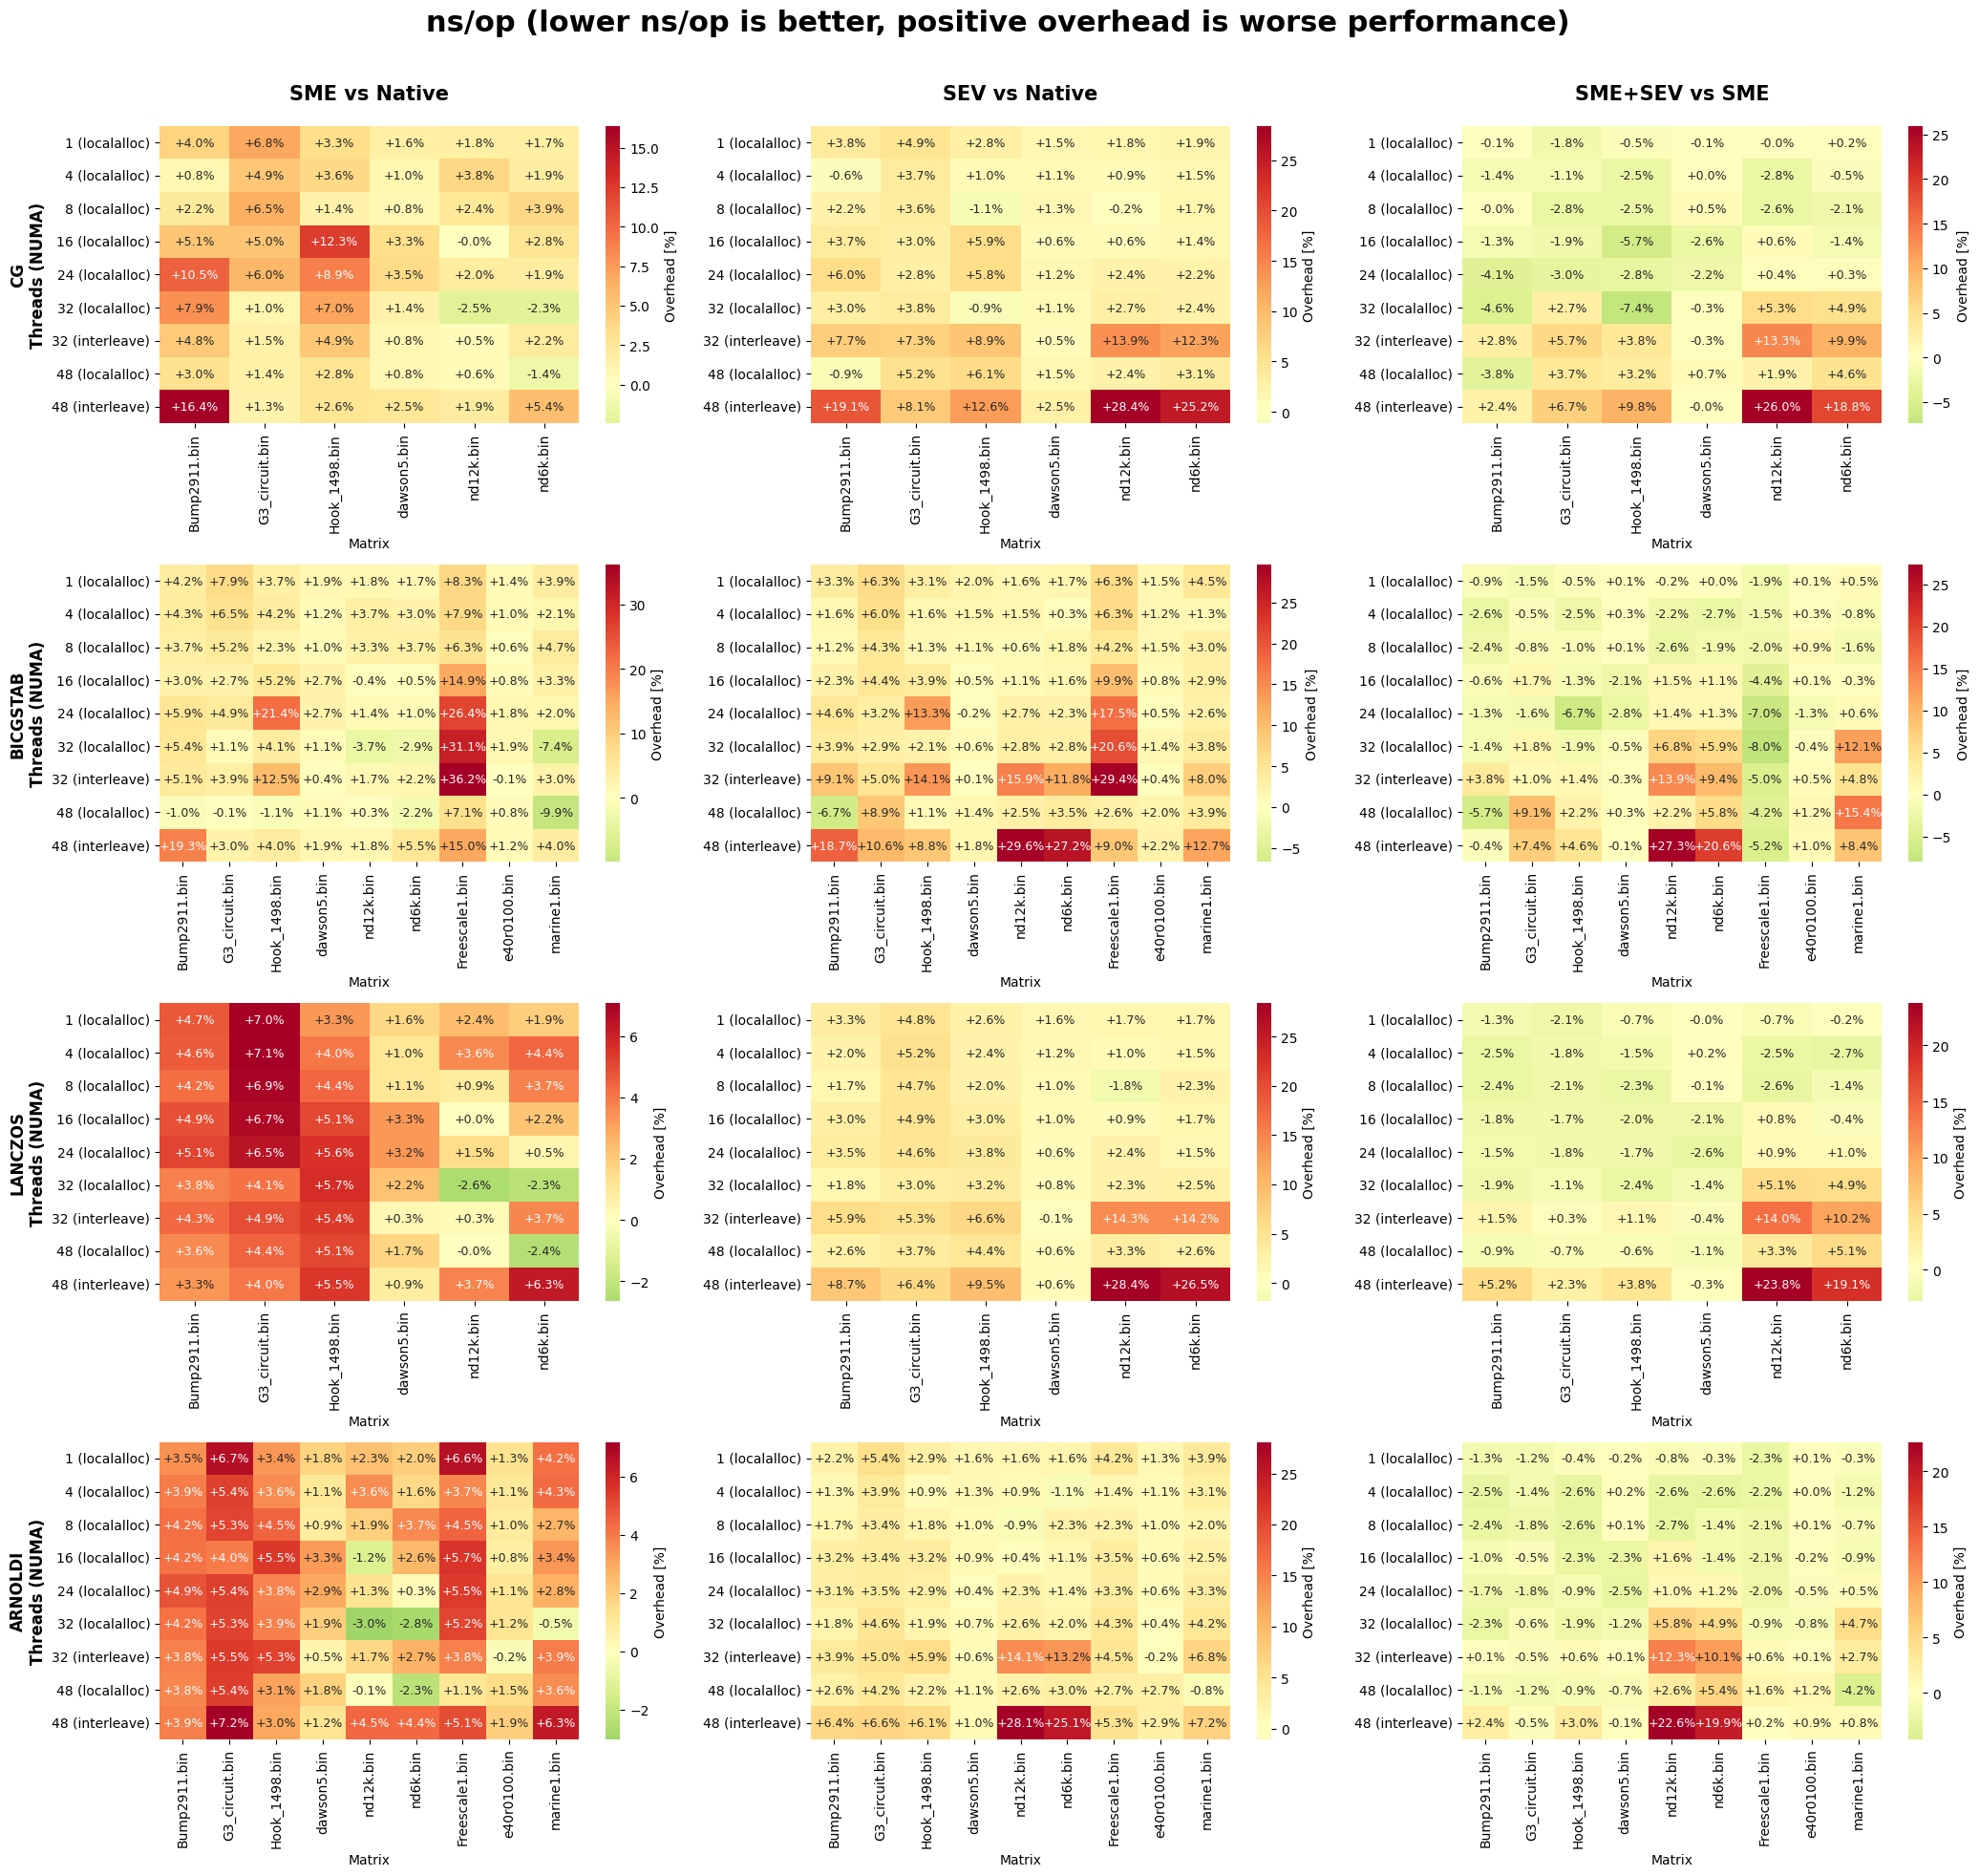

In [6]:
# 1. Daten vorbereiten
heat_df = final_df.copy()
heat_df['Algo'] = heat_df['Algo'].str.lower()  # Vereinheitlichen
heat_df['Matrix_Label'] = heat_df['Matrix'].str.split('/').str[-1]

# --- NUMA Reihenfolge: localalloc zuerst, interleave danach ---
numa_order = ['localalloc', 'interleave']
heat_df['NUMA'] = pd.Categorical(heat_df['NUMA'], categories=numa_order, ordered=True)

# --- SORTIERUNG DER ALGORITHMEN ---
algo_order = ['cg', 'bicgstab', 'lanczos', 'arnoldi']
available_algos = [a for a in algo_order if a in heat_df['Algo'].unique()]
heat_df['Algo'] = pd.Categorical(heat_df['Algo'], categories=available_algos, ordered=True)

# --- SORTIERUNG DER ZEILEN (Cores & NUMA) ---
heat_df = heat_df.sort_values(by=['Cores', 'NUMA'])
heat_df['Threads_Config'] = heat_df['Cores'].astype(str) + " (" + heat_df['NUMA'].astype(str) + ")"
config_order = heat_df[['Cores', 'NUMA', 'Threads_Config']].drop_duplicates().sort_values(['Cores', 'NUMA'])['Threads_Config'].tolist()
heat_df['Threads_Config'] = pd.Categorical(heat_df['Threads_Config'], categories=config_order, ordered=True)

# 2. Grid-Setup
modes_to_plot = ['SME_vs_Native_%', 'SEV_vs_Native_%', 'SEV_vs_SME_%']
mode_titles = ['SME vs Native', 'SEV vs Native', 'SME+SEV vs SME']
unique_algos = available_algos

n_rows = len(unique_algos)
n_cols = len(modes_to_plot)

fig, axes = plt.subplots(
    n_rows, 
    n_cols, 
    figsize=(7 * n_cols, 5 * n_rows),
    sharey=False
)
axes = np.atleast_2d(axes)

# 3. Plot-Schleife
for i, algo in enumerate(unique_algos):
    algo_data = heat_df[heat_df['Algo'] == algo]
    
    for j, (mode_col, title) in enumerate(zip(modes_to_plot, mode_titles)):
        ax = axes[i, j]
        
        if algo_data.empty:
            ax.set_visible(False)
            continue

        heatmap_data = algo_data.pivot_table(
            index='Threads_Config',
            columns='Matrix_Label',
            values=mode_col,
            sort=False,
            observed=False
        )

        sns.heatmap(
            heatmap_data,
            ax=ax,
            cmap='RdYlGn_r',  # invertiert: Grün = niedriger (besser), Rot = höher (schlechter)
            center=0,
            annot=True,
            fmt='+.1f',
            cbar_kws={'label': 'Overhead [%]'},
            annot_kws={"size": 9}
        )

        # Prozentzeichen ergänzen
        for text in ax.texts:
            if text.get_text():
                text.set_text(f"{text.get_text()}%")

        # Beschriftung
        if i == 0:
            ax.set_title(title, fontsize=15, fontweight='bold', pad=20)
        
        if j == 0:
            ax.set_ylabel(f"{algo.upper()}\nThreads (NUMA)", fontsize=12, fontweight='bold')
        else:
            ax.set_ylabel("")
            
        ax.set_xlabel("Matrix")

# 4. Final Layout
plt.suptitle("ns/op (lower ns/op is better, positive overhead is worse performance)", 
             fontsize=22, fontweight='bold', y=0.98)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()